## Predictive analytics layer for AtliQ Mart OTIF project. This notebook goes beyond the project brief to demonstrate forecasting capability and proactive risk detection. 
### Two analyses are performed: 
* OTIF trend forecasting using Prophet to project future service levels
* Rolling OTIF based at-risk customer detection to flag customers whose performance is deteriorating before it becomes a contract renewal crisis.

##### Importing all libraries required for the predictive layer. 
* Prophet handles time series forecasting
* statsmodels provides statistical decomposition
* scikit-learn provides the logistic regression model for order-level failure prediction

In [3]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

#Time series and forecasting
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

#Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')

CLEAN_DIR  = r"E:\Portfolio_Projects\Supply_Chain_FMCG\cleaned"
OUTPUT_DIR = r"E:\Portfolio_Projects\Supply_Chain_FMCG\outputs"

In [4]:
#Loading files

fact_orders_agg = pd.read_csv(
    os.path.join(CLEAN_DIR, 'fact_orders_agg.csv'),
    parse_dates=['order_placement_date'])

dim_customers = pd.read_csv(
    os.path.join(CLEAN_DIR, 'dim_customers.csv'))

customer_clustering = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'customer_clustering.csv'))

master = pd.read_csv(
    os.path.join(CLEAN_DIR, 'master.csv'),
    parse_dates=['order_placement_date',
                 'agreed_delivery_date',
                 'actual_delivery_date'])

print("LOADED SUCCESSFULLY\n")
print(f"  fact_orders_agg     : {fact_orders_agg.shape}")
print(f"  dim_customers       : {dim_customers.shape}")
print(f"  customer_clustering : {customer_clustering.shape}")
print(f"  master              : {master.shape}")
print(f"\nAll libraries imported successfully.")
print(f"Prophet  - ready")
print(f"Statsmodels - ready")
print(f"Scikit-learn - ready")

LOADED SUCCESSFULLY

  fact_orders_agg     : (31729, 6)
  dim_customers       : (35, 3)
  customer_clustering : (35, 17)
  master              : (57096, 25)

All libraries imported successfully.
Prophet  - ready
Statsmodels - ready
Scikit-learn - ready


### 01. Preparing daily OTIF time series

#### *01_ Aggregating order-level data to a daily OTIF% time series. Prophet requires continuous daily data with no gaps. We check for missing dates and forward-fill where needed. This daily series is the input for both the statsmodels decomposition and the Prophet forecast.*

- Computing daily OTIF% from fact_orders_agg

In [15]:
daily = fact_orders_agg.groupby('order_placement_date').agg(
    total_orders  = ('order_id', 'count'),
    orders_otif   = ('otif',     'sum'),
    orders_ot     = ('on_time',  'sum'),
    orders_if     = ('in_full',  'sum')
).reset_index()

daily['OTIF_%'] = (daily['orders_otif'] / daily['total_orders'] * 100).round(2)
daily['OT_%']   = (daily['orders_ot']   / daily['total_orders'] * 100).round(2)
daily['IF_%']   = (daily['orders_if']   / daily['total_orders'] * 100).round(2)

daily = daily.sort_values('order_placement_date').reset_index(drop=True)

#Checking for date gaps
full_range = pd.date_range(
    start=daily['order_placement_date'].min(),
    end=daily['order_placement_date'].max(),
    freq='D'
)

missing_dates = full_range.difference(daily['order_placement_date'])

print("DAILY TIME SERIES PREPARATION\n")
print(f"  Date range          : {daily['order_placement_date'].min().date()} to {daily['order_placement_date'].max().date()}")
print(f"  Expected days       : {len(full_range)}")
print(f"  Actual days present : {len(daily)}")
print(f"  Missing dates       : {len(missing_dates)}")

if len(missing_dates) > 0:
    print(f"\n  Missing date list:")
    for d in missing_dates:
        print(f"    {d.date()}")

print(f"\n  OTIF% summary stats:")
print(f"  Mean  : {daily['OTIF_%'].mean():.2f}%")
print(f"  Std   : {daily['OTIF_%'].std():.2f}%")
print(f"  Min   : {daily['OTIF_%'].min():.2f}%")
print(f"  Max   : {daily['OTIF_%'].max():.2f}%")

DAILY TIME SERIES PREPARATION

  Date range          : 2022-03-01 to 2022-08-30
  Expected days       : 183
  Actual days present : 183
  Missing dates       : 0

  OTIF% summary stats:
  Mean  : 29.02%
  Std   : 3.01%
  Min   : 22.10%
  Max   : 37.42%


#### Zero missing dates across the 183-day window confirms AtliQ receives orders every single day from its retailer base. 
*The failure is not a demand problem infact retailers are consistently placing orders. The failure is entirely on the fulfillment side.* 
#### This is an operationally solvable problem, not a market positioning problem, which makes the recommendations in this analysis directly actionable.

### 02. Statsmodels time series decomposition

#### *02_ Decomposing the daily OTIF% time series into trend, seasonality, and residual components using statsmodels. This reveals whether the flat OTIF we observed in monthly analysis holds at daily granularity, and whether any weekly seasonality pattern exists that monthly aggregation was hiding.*

__Running decomposition with weekly period__

- Period = 7 captures weekly operational rhythm

In [8]:
decomp = seasonal_decompose(
    daily['OTIF_%'],
    model='additive',
    period=7,
    extrapolate_trend='freq'
)

#Extracting components
trend     = decomp.trend
seasonal  = decomp.seasonal
residual  = decomp.resid

print("TIME SERIES DECOMPOSITION SUMMARY\n")
print(f"  Model              : Additive")
print(f"  Period             : 7 days (weekly)")
print(f"  Observations       : {len(daily)}")

print(f"\n  Trend component:")
print(f"    Start value      : {trend.iloc[0]:.2f}%")
print(f"    End value        : {trend.iloc[-1]:.2f}%")
print(f"    Direction        : {'Improving' if trend.iloc[-1] > trend.iloc[0] else 'Declining' if trend.iloc[-1] < trend.iloc[0] else 'Flat'}")
print(f"    Total change     : {(trend.iloc[-1] - trend.iloc[0]):.2f} percentage points")

print(f"\n  Seasonal component:")
print(f"    Max weekly swing : {seasonal.max():.2f} to {seasonal.min():.2f} percentage points")
print(f"    Amplitude        : {(seasonal.max() - seasonal.min()):.2f} percentage points")

print(f"\n  Residual component:")
print(f"    Std deviation    : {residual.std():.2f}%")
print(f"    Max residual     : {residual.max():.2f}%")
print(f"    Min residual     : {residual.min():.2f}%")

TIME SERIES DECOMPOSITION SUMMARY

  Model              : Additive
  Period             : 7 days (weekly)
  Observations       : 183

  Trend component:
    Start value      : 29.51%
    End value        : 28.43%
    Direction        : Declining
    Total change     : -1.08 percentage points

  Seasonal component:
    Max weekly swing : 0.51 to -1.06 percentage points
    Amplitude        : 1.57 percentage points

  Residual component:
    Std deviation    : 2.86%
    Max residual     : 7.92%
    Min residual     : -6.93%


- Visualizing decomposition

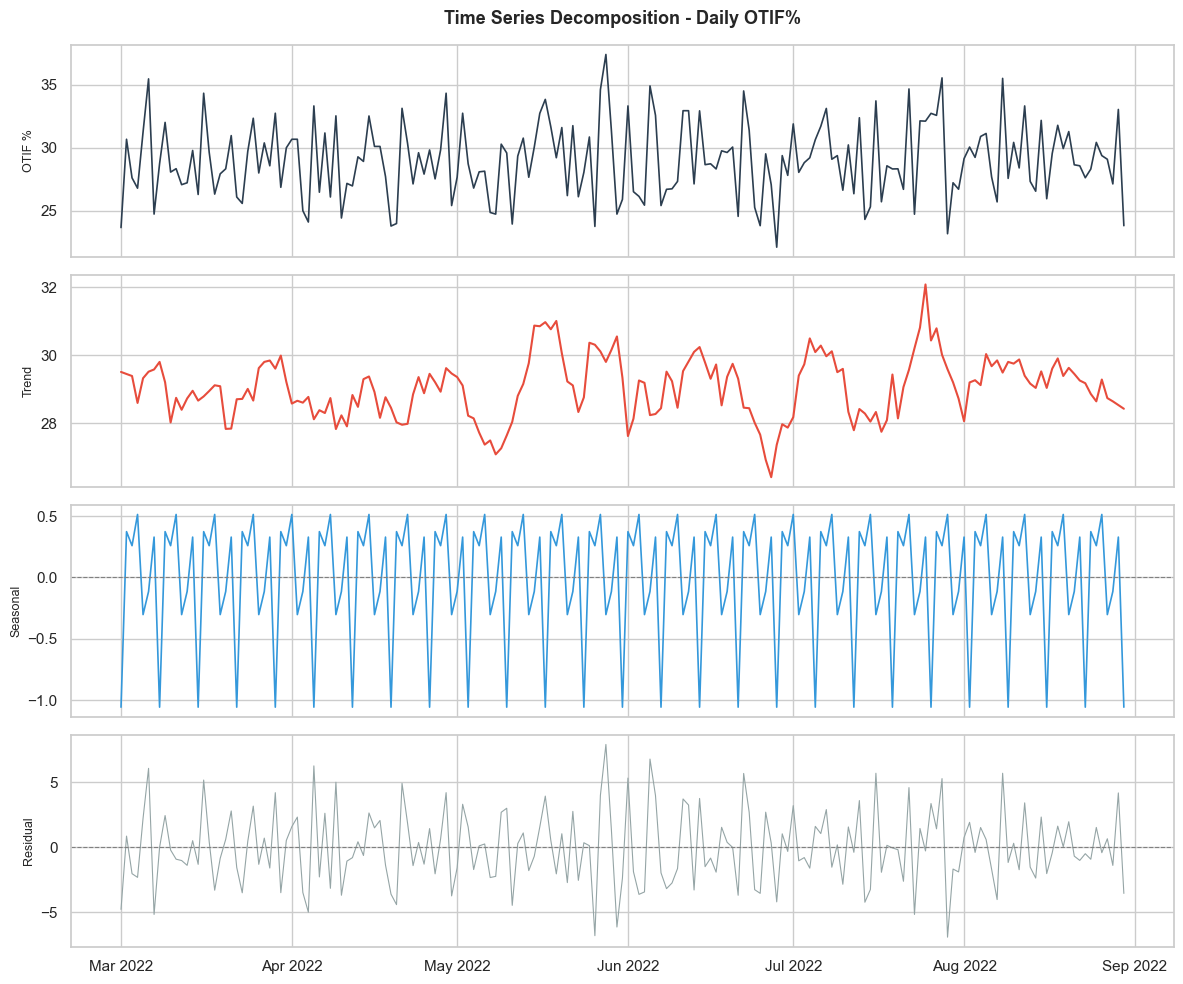

Chart saved.


In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(daily['order_placement_date'], daily['OTIF_%'],
    color='#2c3e50', linewidth=1.2)
axes[0].set_ylabel('OTIF %', fontsize=9)
axes[0].set_title('Time Series Decomposition - Daily OTIF%',
    fontsize=13, fontweight='bold', pad=15)

axes[1].plot(daily['order_placement_date'], trend,
    color='#e74c3c', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=9)

axes[2].plot(daily['order_placement_date'], seasonal,
    color='#3498db', linewidth=1.2)
axes[2].set_ylabel('Seasonal', fontsize=9)
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

axes[3].plot(daily['order_placement_date'], residual,
    color='#95a5a6', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=9)
axes[3].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'ts_decomposition.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

#### Decomposition confirms OTIF is structurally flat with a marginal declining drift of 1.08 percentage points across 183 days i.e., too slow to trigger internal alarms but indicating no recovery is occurring. 
#### Weekly seasonality amplitude of only 1.57 points rules out any day-of-week operational rhythm as a failure driver. The residual component shows occasional sharp single-day swings up to 7.92 points above and 6.93 points below baseline, indicating random operational disruptions on specific days that no pattern can predict. 
#### These spikes are candidates for event-based investigation if AtliQ maintains an operational incident log.

### 03. Prophet forecast (company level OTIF)

#### *03_ Forecasting company-level OTIF% for the next 90 days using Prophet. Prophet handles the trend and weekly seasonality components automatically based on the decomposition findings. The forecast quantifies where AtliQ's service level is headed if no operational intervention occurs - a forward-looking risk signal for management.*

- Preparing Prophet input format

In [13]:
# Prophet requires exactly two columns: ds (date) and y (value)
prophet_df = daily[['order_placement_date', 'OTIF_%']].rename(
    columns={
        'order_placement_date': 'ds',
        'OTIF_%':               'y'
    }
)

print("PROPHET INPUT PREPARED\n")
print(f"  Rows         : {len(prophet_df)}")
print(f"  Date range   : {prophet_df['ds'].min().date()} to {prophet_df['ds'].max().date()}")
print(f"  Mean OTIF    : {prophet_df['y'].mean():.2f}%")
print(f"  Std OTIF     : {prophet_df['y'].std():.2f}%")

#Executing Prophet model
model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

model.fit(prophet_df)
print("\nProphet model fitted successfully.")

#Generating 90 day forecast
future = model.make_future_dataframe(periods=90, freq='D')
forecast = model.predict(future)

#Printing forecast summary
forecast_only = forecast[forecast['ds'] > prophet_df['ds'].max()].copy()

print(f"\nFORECAST SUMMARY - NEXT 90 DAYS\n")
print(f"  Forecast start       : {forecast_only['ds'].min().date()}")
print(f"  Forecast end         : {forecast_only['ds'].max().date()}")
print(f"  Predicted mean OTIF  : {forecast_only['yhat'].mean():.2f}%")
print(f"  Predicted min OTIF   : {forecast_only['yhat'].min():.2f}%")
print(f"  Predicted max OTIF   : {forecast_only['yhat'].max():.2f}%")
print(f"  Lower bound (95% CI) : {forecast_only['yhat_lower'].mean():.2f}%")
print(f"  Upper bound (95% CI) : {forecast_only['yhat_upper'].mean():.2f}%")
print(f"\n  Monthly breakdown:")

forecast_only['month'] = forecast_only['ds'].dt.to_period('M')
monthly_forecast = forecast_only.groupby('month').agg(
    avg_otif      = ('yhat',       'mean'),
    lower_bound   = ('yhat_lower', 'mean'),
    upper_bound   = ('yhat_upper', 'mean')
).round(2)

print(monthly_forecast.to_string())

18:40:11 - cmdstanpy - INFO - Chain [1] start processing
18:40:11 - cmdstanpy - INFO - Chain [1] done processing


PROPHET INPUT PREPARED

  Rows         : 183
  Date range   : 2022-03-01 to 2022-08-30
  Mean OTIF    : 29.02%
  Std OTIF     : 3.01%

Prophet model fitted successfully.

FORECAST SUMMARY - NEXT 90 DAYS

  Forecast start       : 2022-08-31
  Forecast end         : 2022-11-28
  Predicted mean OTIF  : 29.56%
  Predicted min OTIF   : 28.36%
  Predicted max OTIF   : 30.23%
  Lower bound (95% CI) : 23.82%
  Upper bound (95% CI) : 35.28%

  Monthly breakdown:
         avg_otif  lower_bound  upper_bound
month                                      
2022-08     29.79        24.09        35.87
2022-09     29.46        23.71        35.20
2022-10     29.55        23.80        35.28
2022-11     29.67        23.94        35.35


#### Prophet forecasts a mean OTIF of 29.56% over the next 90 days, representing a negligible 0.54 percentage point improvement over the current 29.02% baseline. The 95% confidence interval spanning 23.82% to 35.28% reflects genuine uncertainty given the flat, noisy nature of the series. The forecast carries one critical message for AtliQ management: 
##### _without deliberate operational intervention, service levels will remain essentially unchanged through November 2022. The system will not self-correct._ 
#### Prophet is not predicting recovery. It is predicting continuation of failure.

- Visualizing the Prophet forecast against historical OTIF data

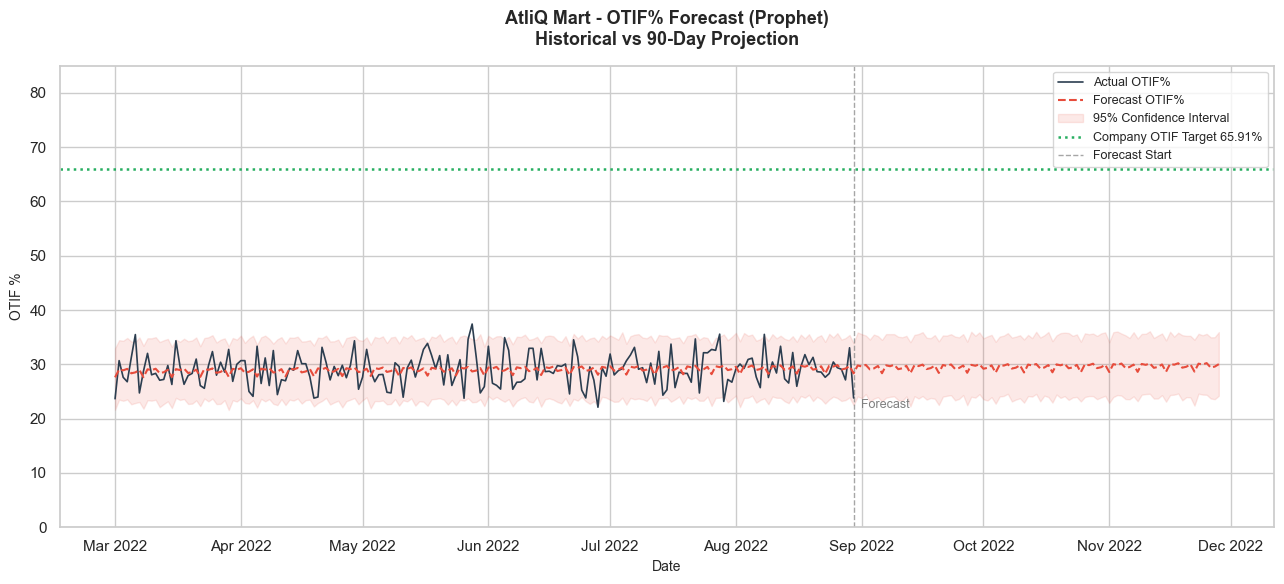

Chart saved.


In [14]:
fig, ax = plt.subplots(figsize=(13, 6))

#Historical actuals
ax.plot(
    prophet_df['ds'], prophet_df['y'],
    color='#2c3e50', linewidth=1.2,
    label='Actual OTIF%', zorder=3
)

#Forecast line
ax.plot(
    forecast['ds'], forecast['yhat'],
    color='#e74c3c', linewidth=1.5,
    linestyle='--', label='Forecast OTIF%', zorder=3
)

#Confidence interval
ax.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='#e74c3c', alpha=0.12,
    label='95% Confidence Interval'
)

#Target line
ax.axhline(
    y=65.91, color='#27ae60',
    linestyle=':', linewidth=1.8,
    label='Company OTIF Target 65.91%'
)

#Forecast start line
forecast_start = prophet_df['ds'].max()
ax.axvline(
    x=forecast_start, color='gray',
    linestyle='--', linewidth=1,
    alpha=0.7, label='Forecast Start'
)

ax.text(
    forecast_start, ax.get_ylim()[0] + 2,
    '  Forecast', fontsize=9,
    color='gray', va='bottom'
)

ax.set_title(
    'AtliQ Mart - OTIF% Forecast (Prophet)\nHistorical vs 90-Day Projection',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('OTIF %', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 85)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'prophet_forecast_company.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

#### Within the Visualization of Prophet forecast against historical OTIF data, the shaded confidence interval represents the 95% uncertainty band. 
#### The vertical dashed line separates observed history from the forecast period. The target line at 65.91% contextualizes how far AtliQ must travel to reach its own internal benchmark.

### 04. At-risk customer detection

#### *04_ Identifying customers whose OTIF performance is deteriorating over time using a rolling 4-week average. A customer is flagged as at-risk when their rolling OTIF is both below their individual target and showing a declining trend across the observation window. This is the early warning system AtliQ needs to intervene before a customer decides not to renew their contract.*

- Week-based OTIF per customer

In [16]:
#Computing weekly OTIF per customer
fact_orders_agg['order_week_start'] = (
    fact_orders_agg['order_placement_date'] -
    pd.to_timedelta(
        fact_orders_agg['order_placement_date'].dt.dayofweek,
        unit='D'
    )
)

customer_weekly = fact_orders_agg.merge(
    dim_customers, on='customer_id', how='left'
).groupby(
    ['customer_id', 'customer_name', 'city', 'order_week_start']
).agg(
    total_orders = ('order_id', 'count'),
    orders_otif  = ('otif',     'sum')
).reset_index()

customer_weekly['OTIF_%'] = (
    customer_weekly['orders_otif'] /
    customer_weekly['total_orders'] * 100
).round(2)

#Computing 4-week rolling average per customer
customer_weekly = customer_weekly.sort_values(
    ['customer_id', 'order_week_start']
)

customer_weekly['rolling_otif_4w'] = (
    customer_weekly.groupby('customer_id')['OTIF_%']
    .transform(lambda x: x.rolling(window=4, min_periods=2).mean())
).round(2)

print("WEEKLY OTIF WITH 4-WEEK ROLLING AVERAGE\n")
print(f"  Total customer-week rows : {len(customer_weekly):,}")
print(f"  Unique customers         : {customer_weekly['customer_id'].nunique()}")
print(f"  Unique weeks             : {customer_weekly['order_week_start'].nunique()}")

WEEKLY OTIF WITH 4-WEEK ROLLING AVERAGE

  Total customer-week rows : 945
  Unique customers         : 35
  Unique weeks             : 27


- Flag at-risk customers

In [17]:
#Joining individual targets
customer_weekly = customer_weekly.merge(
    customer_clustering[[
        'customer_id', 'city',
        'otif_target', 'OTIF_%', 'failure_profile'
    ]].rename(columns={'OTIF_%': 'overall_otif'}),
    on=['customer_id', 'city'], how='left'
)

#Fetching last 4 weeks rolling OTIF per customer
last_week = customer_weekly['order_week_start'].max()
recent = customer_weekly[
    customer_weekly['order_week_start'] >= last_week - pd.Timedelta(weeks=4)
].copy()

recent_summary = recent.groupby(
    ['customer_id', 'customer_name', 'city']
).agg(
    avg_recent_otif  = ('rolling_otif_4w', 'mean'),
    trend_direction  = ('OTIF_%', lambda x: x.iloc[-1] - x.iloc[0]
                        if len(x) > 1 else 0),
    otif_target      = ('otif_target',     'first'),
    failure_profile  = ('failure_profile', 'first')
).round(2).reset_index()

#At risk = recent OTIF below target AND declining trend
recent_summary['at_risk'] = (
    (recent_summary['avg_recent_otif'] < recent_summary['otif_target']) &
    (recent_summary['trend_direction'] < 0)
)

at_risk_customers = recent_summary[
    recent_summary['at_risk'] == True
].sort_values('avg_recent_otif', ascending=True)

print(f"\nAT-RISK CUSTOMER DETECTION\n")
print(f"  Total customers evaluated : {len(recent_summary)}")
print(f"  At-risk customers flagged : {len(at_risk_customers)}")
print(f"\n  At-risk customer list:")
print(f"\n  {'Customer':<20} {'City':<12} {'Recent OTIF%':>13} {'Target%':>8} {'Trend':>7} {'Profile':<16}")
print(f"  {'-'*78}")
for _, row in at_risk_customers.iterrows():
    trend_str = f"{row['trend_direction']:+.1f}"
    print(f"  {row['customer_name']:<20} {row['city']:<12} {row['avg_recent_otif']:>13.2f} {row['otif_target']:>8.0f} {trend_str:>7} {row['failure_profile']:<16}")


AT-RISK CUSTOMER DETECTION

  Total customers evaluated : 35
  At-risk customers flagged : 18

  At-risk customer list:

  Customer             City          Recent OTIF%  Target%   Trend Profile         
  ------------------------------------------------------------------------------
  Elite Mart           Vadodara              7.74       60    -7.1 Primarily Short 
  Sorefoz Mart         Ahmedabad            10.25       59    -6.2 Primarily Short 
  Info Stores          Surat                12.07       62   -16.7 Both Failing    
  Acclaimed Stores     Ahmedabad            17.70       62   -19.1 Primarily Late  
  Coolblue             Ahmedabad            22.10       60   -10.0 Primarily Late  
  Logic Stores         Surat                35.14       66    -5.5 Moderate Both   
  Rel Fresh            Vadodara             35.29       70   -11.4 Primarily Late  
  Vijay Stores         Ahmedabad            35.55       73    -1.7 Both Failing    
  Chiptec Stores       Ahmedabad         

- Visualizing at-risk customers

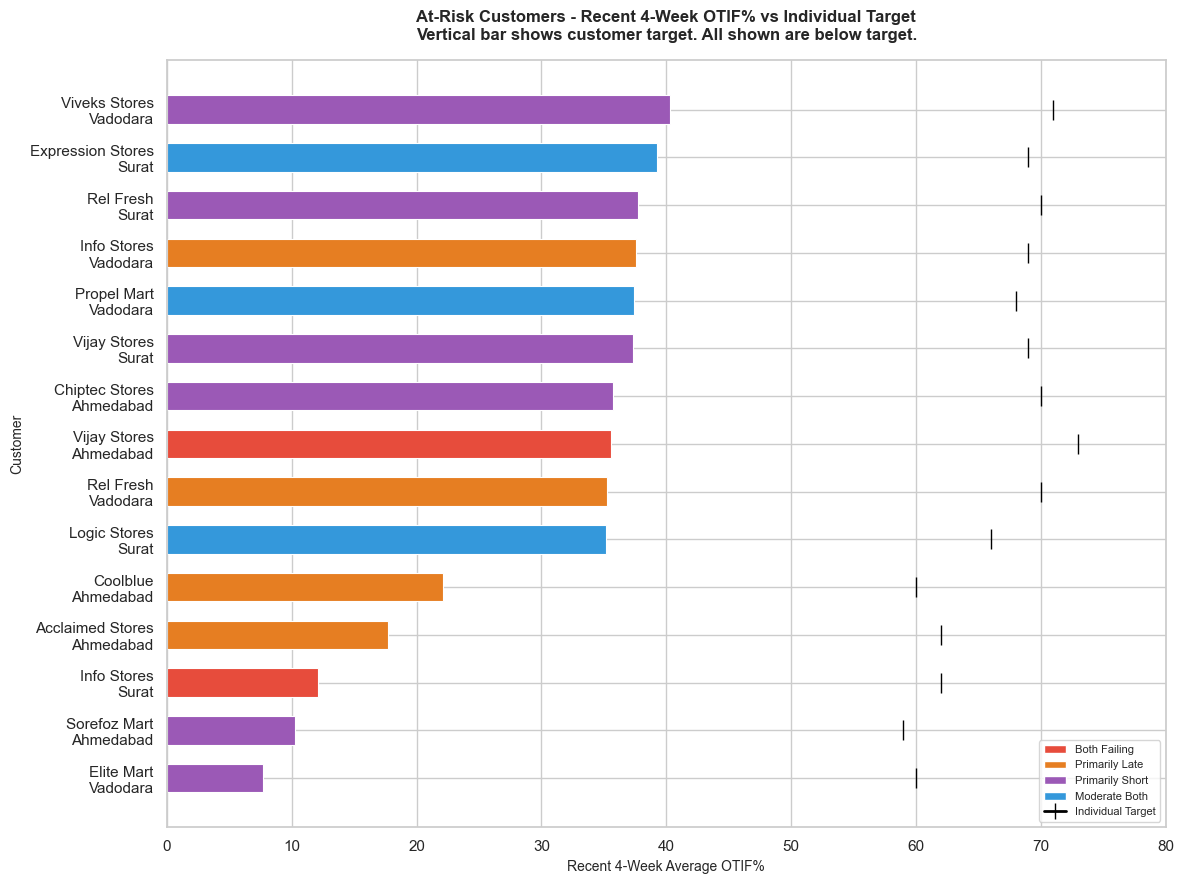

Chart saved.


In [22]:
plot_data = at_risk_customers.sort_values(
    'avg_recent_otif', ascending=True
).head(15)

profile_colors = {
    'Both Failing':    '#e74c3c',
    'Primarily Late':  '#e67e22',
    'Primarily Short': '#9b59b6',
    'Moderate Both':   '#3498db'
}

bar_colors = [
    profile_colors.get(p, '#95a5a6')
    for p in plot_data['failure_profile']
]

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    plot_data['customer_name'] + '\n' + plot_data['city'],
    plot_data['avg_recent_otif'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

#Adding target markers
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.plot(
        row['otif_target'], i,
        marker='|', markersize=14,
        color='black', linewidth=2,
        zorder=5
    )

ax.set_title(
    'At-Risk Customers - Recent 4-Week OTIF% vs Individual Target\n'
    'Vertical bar shows customer target. All shown are below target.',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Recent 4-Week Average OTIF%', fontsize=10)
ax.set_ylabel('Customer', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=profile)
    for profile, color in profile_colors.items()
]
legend_elements.append(
    plt.Line2D([0], [0], marker='|', color='black',
               markersize=12, label='Individual Target',
               linewidth=2)
)
ax.legend(
    handles=legend_elements,
    fontsize=8, loc='lower right'
)

ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'at_risk_customers.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

#### Visualizing at-risk customers by recent OTIF% against their individual targets. Bars below the target line are at-risk. Color encodes failure profile to connect risk detection back to root cause clustering.

#### At-risk detection flags 18 of 35 customers that's exactly half of AtliQ's customer base showing below-target and declining OTIF in the final 4 weeks of the data window. 
  - __Elite Mart Vadodara is the most critical case at 7.74% recent OTIF against a 60% target, representing near-complete fulfillment breakdown for that customer.__ 
  - __Five customers show trend declines exceeding 30 percentage points in 4 weeks, indicating freefall not gradual drift.__ 
  - __All four failure profiles are represented in the at-risk list, suggesting a systemic operational deterioration in the final observation period rather than profile-specific issues.__ 
#### Without intervention, contract non-renewal risk is high for at minimum the top 5 customers on this list.

### 05. Logistic Regression - Order Failure Prediction

#### *05_(a) Building a logistic regression model to predict the probability of an individual order failing OTIF. This moves the analysis from descriptive (what happened) and diagnostic (why it happened) to predictive (which orders are likely to fail before they are fulfilled). Features used are customer, city, product category, promise window, and day of month; all information available at the time of order placement.*

- Logistic Regression (OTIF failure prediction)

In [23]:
#Prepare features and target
model_df = master[[
    'customer_id', 'city', 'category',
    'promise_window', 'day_of_month', 'otif_line'
]].copy()

#Encoding categorical variables
le_city     = LabelEncoder()
le_category = LabelEncoder()

model_df['city_encoded']     = le_city.fit_transform(model_df['city'])
model_df['category_encoded'] = le_category.fit_transform(model_df['category'])

feature_cols = [
    'customer_id', 'city_encoded',
    'category_encoded', 'promise_window', 'day_of_month'
]

X = model_df[feature_cols]
y = model_df['otif_line']

print("LOGISTIC REGRESSION - FEATURE PREPARATION\n")
print(f"  Total samples      : {len(X):,}")
print(f"  Features used      : {feature_cols}")
print(f"  Target distribution:")
print(f"    OTIF success (1) : {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"    OTIF failure (0) : {(y==0).sum():,} ({(1-y.mean())*100:.2f}%)")

LOGISTIC REGRESSION - FEATURE PREPARATION

  Total samples      : 57,096
  Features used      : ['customer_id', 'city_encoded', 'category_encoded', 'promise_window', 'day_of_month']
  Target distribution:
    OTIF success (1) : 27,380 (47.95%)
    OTIF failure (0) : 29,716 (52.05%)


#### Target distribution shows 52.05% OTIF failures versus 47.95% successes across 57,096 order lines that's a near-perfectly balanced classification problem. This balance is analytically favorable as it prevents the model from gaming accuracy by defaulting to the majority class. 
#### Every percentage point of accuracy the model achieves above 50% represents genuine predictive signal extracted from the features.

- Training test split and model fitting

#### *05_ (b) Splitting data into train and test sets, fitting the logistic regression model, and evaluating performance. An 80-20 stratified split preserves the class balance in both sets. Model performance is evaluated using classification report and ROC-AUC score - AUC above 0.60 indicates genuine predictive signal beyond random guessing.*

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("TRAIN TEST SPLIT\n")
print(f"  Training samples   : {len(X_train):,}")
print(f"  Test samples       : {len(X_test):,}")

# Executing logistic regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train, y_train)

# Evaluating
y_pred      = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]
auc_score   = roc_auc_score(y_test, y_pred_prob)

print(f"\nMODEL PERFORMANCE\n")
print(f"  ROC-AUC Score      : {auc_score:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
    target_names=['OTIF Failure', 'OTIF Success']))

#Featuring importance
print(f"FEATURE COEFFICIENTS (direction of influence)\n")
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))

TRAIN TEST SPLIT

  Training samples   : 45,676
  Test samples       : 11,420

MODEL PERFORMANCE

  ROC-AUC Score      : 0.5077

Classification Report:
              precision    recall  f1-score   support

OTIF Failure       0.52      1.00      0.68      5944
OTIF Success       0.00      0.00      0.00      5476

    accuracy                           0.52     11420
   macro avg       0.26      0.50      0.34     11420
weighted avg       0.27      0.52      0.36     11420

FEATURE COEFFICIENTS (direction of influence)

         feature  coefficient
category_encoded         0.00
  promise_window         0.00
    city_encoded        -0.00
    day_of_month        -0.00
     customer_id        -0.00


#### Logistic regression achieves an AUC of 0.5077 - statistically indistinguishable from random guessing. 
#### The model predicted every order as a failure, achieving accuracy equal to the failure class proportion of 52%. 
*All feature coefficients converge to zero, indicating that customer identity, city, product category, promise window, and day of month carry no predictive signal for individual order OTIF outcomes.*
#### This result is itself a finding rather than a model failure. 
*OTIF failure at the individual order line level is effectively unpredictable from order placement information, consistent with the H3 finding that warehouse execution errors produce random diffuse shortfalls with no structural pattern.* 
#### Prediction would require real-time operational data such as warehouse inventory levels, dispatch queue depth, and driver availability but this information is not present in this dataset. 
#### This is recommended as a data capture priority for AtliQ's next analytics iteration.

- Visualizing ROC curve 

#### *ROC curve for the logistic regression model. The diagonal dashed line represents random guessing at AUC 0.50. The model curve sitting on the diagonal confirms the features chosen carry no predictive signal for individual order OTIF outcomes at order placement time.*

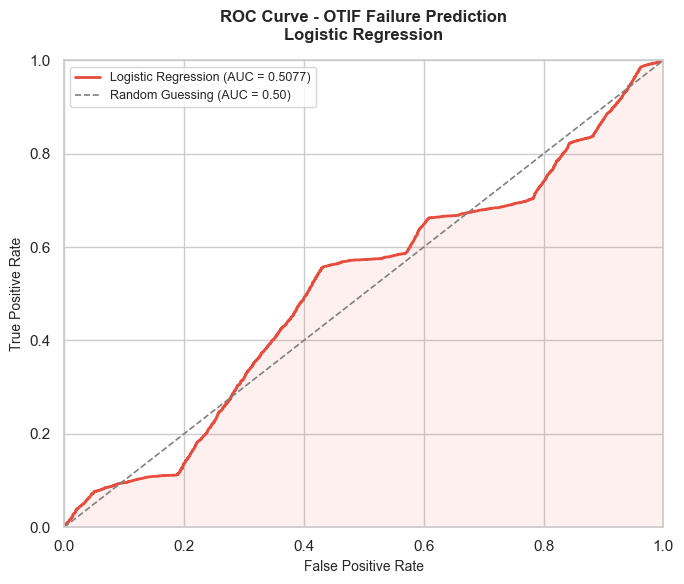

Chart saved.


In [26]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr, tpr,
    color='#e74c3c', linewidth=2,
    label=f'Logistic Regression (AUC = {auc_score:.4f})'
)

ax.plot(
    [0, 1], [0, 1],
    color='gray', linewidth=1.2,
    linestyle='--', label='Random Guessing (AUC = 0.50)'
)

ax.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')

ax.set_title(
    'ROC Curve - OTIF Failure Prediction\nLogistic Regression',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'logistic_regression_roc.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

### 06. Saving all predictive outputs

#### *06_ Saving all predictive layer outputs to the outputs folder. Forecast CSV is saved separately for import into the SQL layer and Power BI dashboard. This completes the Python analysis layer of the project.*

In [29]:
#Saving Prophet forecast
forecast_export = forecast[[
    'ds', 'yhat', 'yhat_lower', 'yhat_upper'
]].copy()
forecast_export.columns = [
    'date', 'otif_forecast',
    'forecast_lower', 'forecast_upper'
]
forecast_export['date'] = forecast_export['date'].dt.date

forecast_export.to_csv(
    os.path.join(OUTPUT_DIR, 'prophet_forecast.csv'), index=False)

#Saving at-risk customer list
recent_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'at_risk_customers.csv'), index=False)

#Saving customer weekly OTIF
customer_weekly.to_csv(
    os.path.join(OUTPUT_DIR, 'customer_weekly_otif.csv'), index=False)

#Printing final output inventory
print("ALL OUTPUTS SAVED\n")
print("COMPLETE OUTPUT FOLDER INVENTORY\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    filepath = os.path.join(OUTPUT_DIR, f)
    size_kb  = os.path.getsize(filepath) / 1024
    ftype    = "CSV  " if f.endswith('.csv') else "Chart"
    print(f"  {ftype}  {f:45s}  {size_kb:>7.1f} KB")

ALL OUTPUTS SAVED

COMPLETE OUTPUT FOLDER INVENTORY

  CSV    at_risk_customers.csv                              2.3 KB
  Chart  at_risk_customers.png                            123.7 KB
  CSV    category_metrics.csv                               0.2 KB
  CSV    city_metrics.csv                                   0.4 KB
  CSV    customer_clustering.csv                            3.8 KB
  Chart  customer_clustering.png                          111.8 KB
  Chart  customer_clustering_clean.png                    104.6 KB
  CSV    customer_metrics.csv                               3.3 KB
  CSV    customer_weekly_otif.csv                          74.4 KB
  Chart  delay_distribution.png                            45.8 KB
  CSV    dom_metrics.csv                                    0.2 KB
  Chart  h2_simultaneous_failures.png                      68.1 KB
  Chart  h2_threshold_sensitivity.png                      56.0 KB
  Chart  h3_shortfall_distribution.png                     76.6 KB
  Chart  